In [3]:
%load_ext autoreload
%autoreload 2

import parse_data

parse_data.remove_commas_recursively("/Users/cameronliu/Desktop/Research/Datasets/sd-0.0025-exp-reformatted")

global_sd = 0.0025
tskit = True if global_sd == 0.0025 else False




In [4]:
# Cell to calculate all the information to parse the information from the file 
# Need to develop a system to create a new file that's easier and faster to read the data from

import matplotlib.pyplot as plt
import numpy as np    
from scipy import stats
import statistics
import math

# This is my own .py file, with methods that I have created myself.
import parse_data

pop_size = 2000
burnin = 4*pop_size

# Set global theme settings for plotting
plt.rcParams.update({
    'font.size': 20,          # Set font size
    'lines.linewidth': 3,     # Set default line thickness
    'axes.titlesize': 20,     # Title font size
    'axes.labelsize': 18,     # Axis label font size
    'xtick.labelsize': 14,    # X-tick label font size
    'ytick.labelsize': 14,    # Y-tick label font size
    'grid.color': 'gray',     # Grid color
    'grid.linestyle': '--',   # Grid line style
    'grid.linewidth': 0.5,    # Grid line width
    'legend.fontsize': 16     # Legend font size
})

uds = [0.01, 0.02, 0.03, 0.05, 0.075, 0.1, 0.2, 0.35, 0.5, 0.75, 1, 1.25, 1.5, 2, 4, 6, 8]
wanted = [0.01, 0.02, 0.03, 0.05, 0.075, 0.1, 0.2, 0.35, 0.5, 0.75, 1, 1.25, 1.5, 2, 4, 6, 8]
uds.sort(); wanted.sort()

# These are important to remember
# parse_exp([uds], sd, BURNIN, COMMA)
data, timesteps = parse_data.parse_exp(wanted, global_sd, tskit)
sliced_data, sliced_timesteps = parse_data.slice_data(data, timesteps, burnin)

# sliced_data's format = (sd, (ud, f. sel. deaths))


------------------------
Successfully Parsed Exponential Data for file SD = 0.0025, UD = 0.01
------------------------

------------------------
Successfully Parsed Exponential Data for file SD = 0.0025, UD = 0.02
------------------------

------------------------
Successfully Parsed Exponential Data for file SD = 0.0025, UD = 0.03
------------------------

------------------------
Successfully Parsed Exponential Data for file SD = 0.0025, UD = 0.05
------------------------

------------------------
Successfully Parsed Exponential Data for file SD = 0.0025, UD = 0.075
------------------------

------------------------
Successfully Parsed Exponential Data for file SD = 0.0025, UD = 0.1
------------------------

------------------------
Successfully Parsed Exponential Data for file SD = 0.0025, UD = 0.2
------------------------

------------------------
Successfully Parsed Exponential Data for file SD = 0.0025, UD = 0.35
------------------------

------------------------
Successfully Par

In [9]:
parse_data.find_negative(sliced_data)

no - found in sd-0.0025 0.01
no - found in sd-0.0025 0.02
no - found in sd-0.0025 0.03
no - found in sd-0.0025 0.05
no - found in sd-0.0025 0.075
no - found in sd-0.0025 0.1
no - found in sd-0.0025 0.2
no - found in sd-0.0025 0.35
no - found in sd-0.0025 0.5
no - found in sd-0.0025 0.75
no - found in sd-0.0025 1
no - found in sd-0.0025 1.25
no - found in sd-0.0025 1.5
no - found in sd-0.0025 2
no - found in sd-0.0025 4
no - found in sd-0.0025 6
no - found in sd-0.0025 8


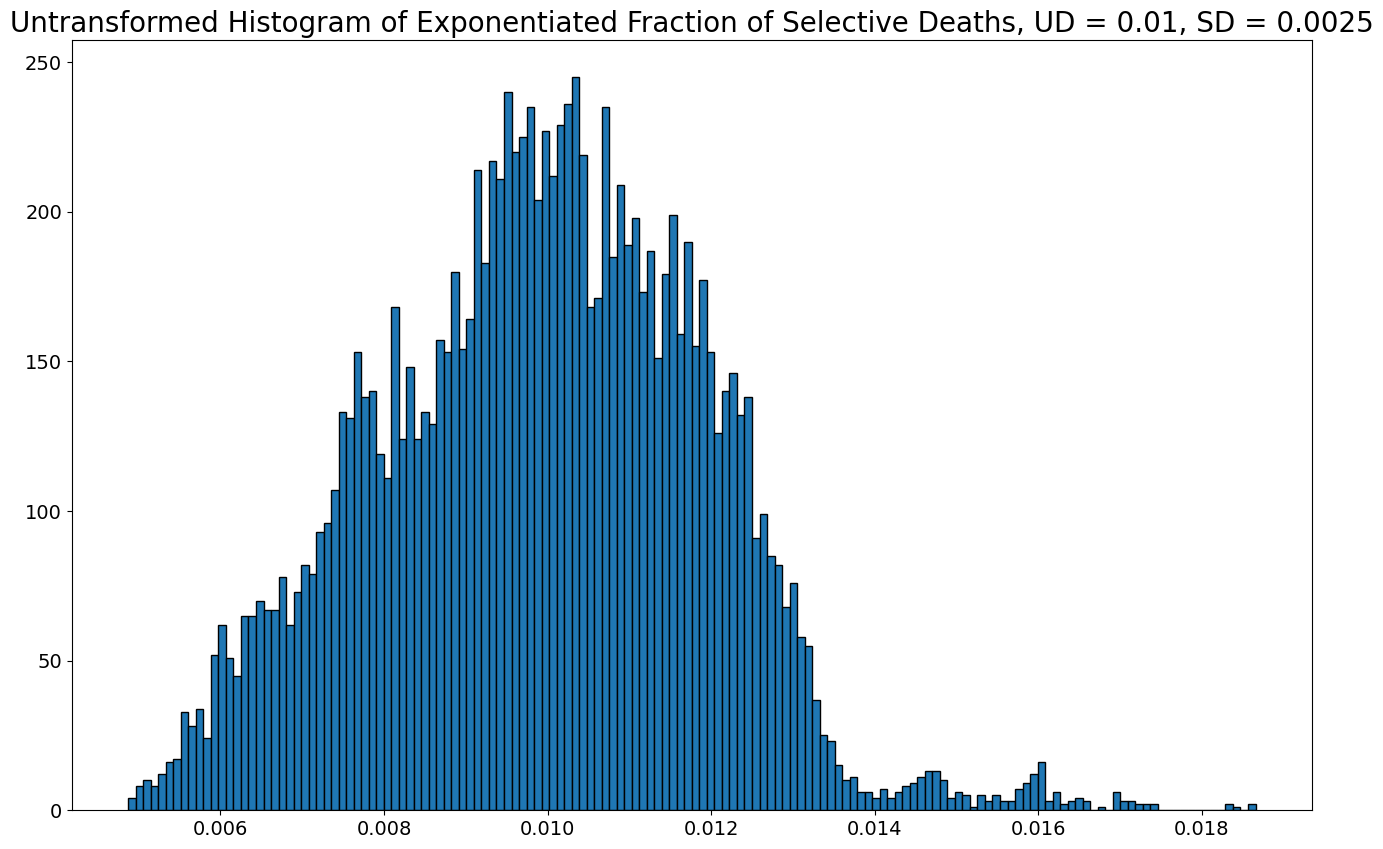

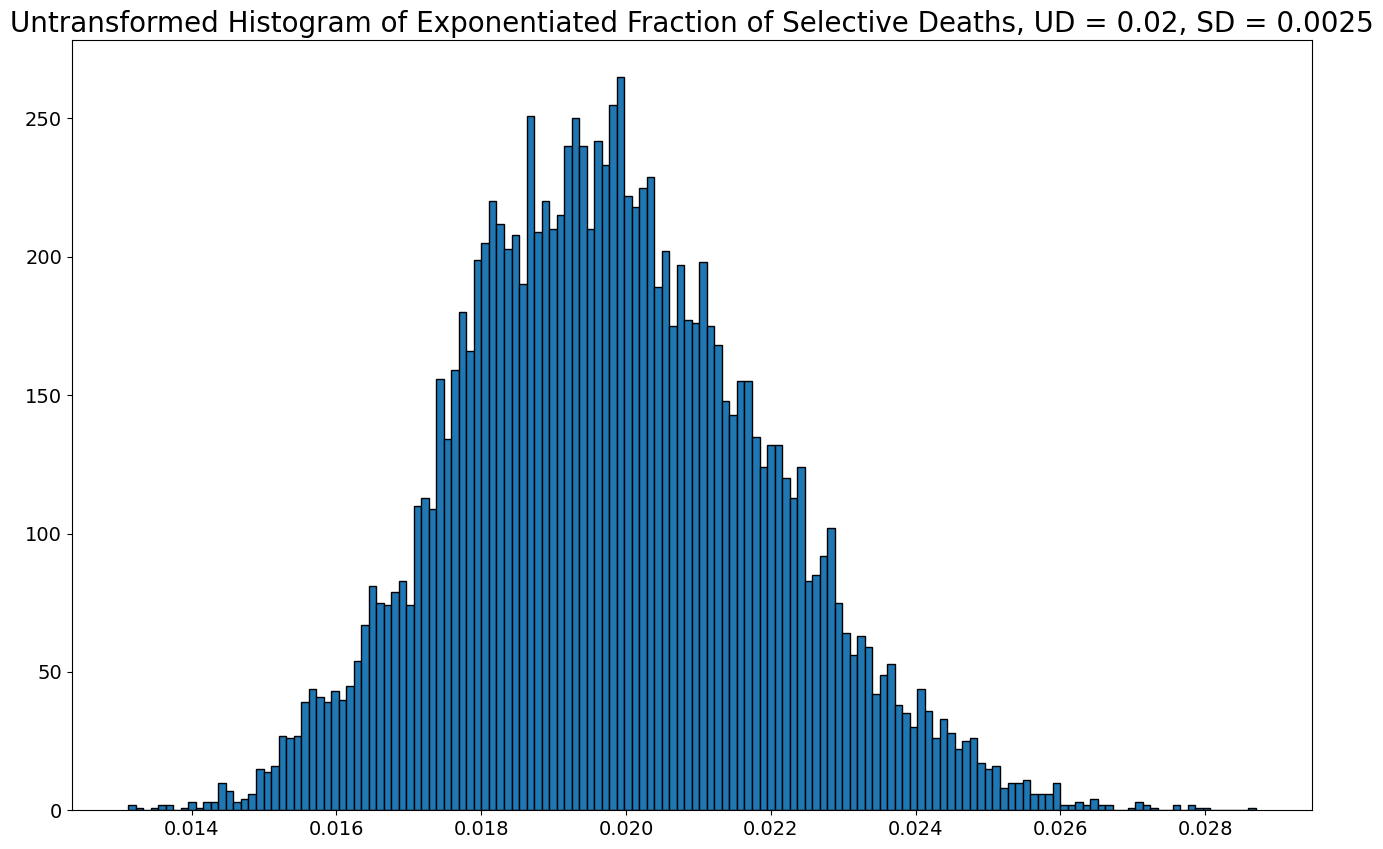

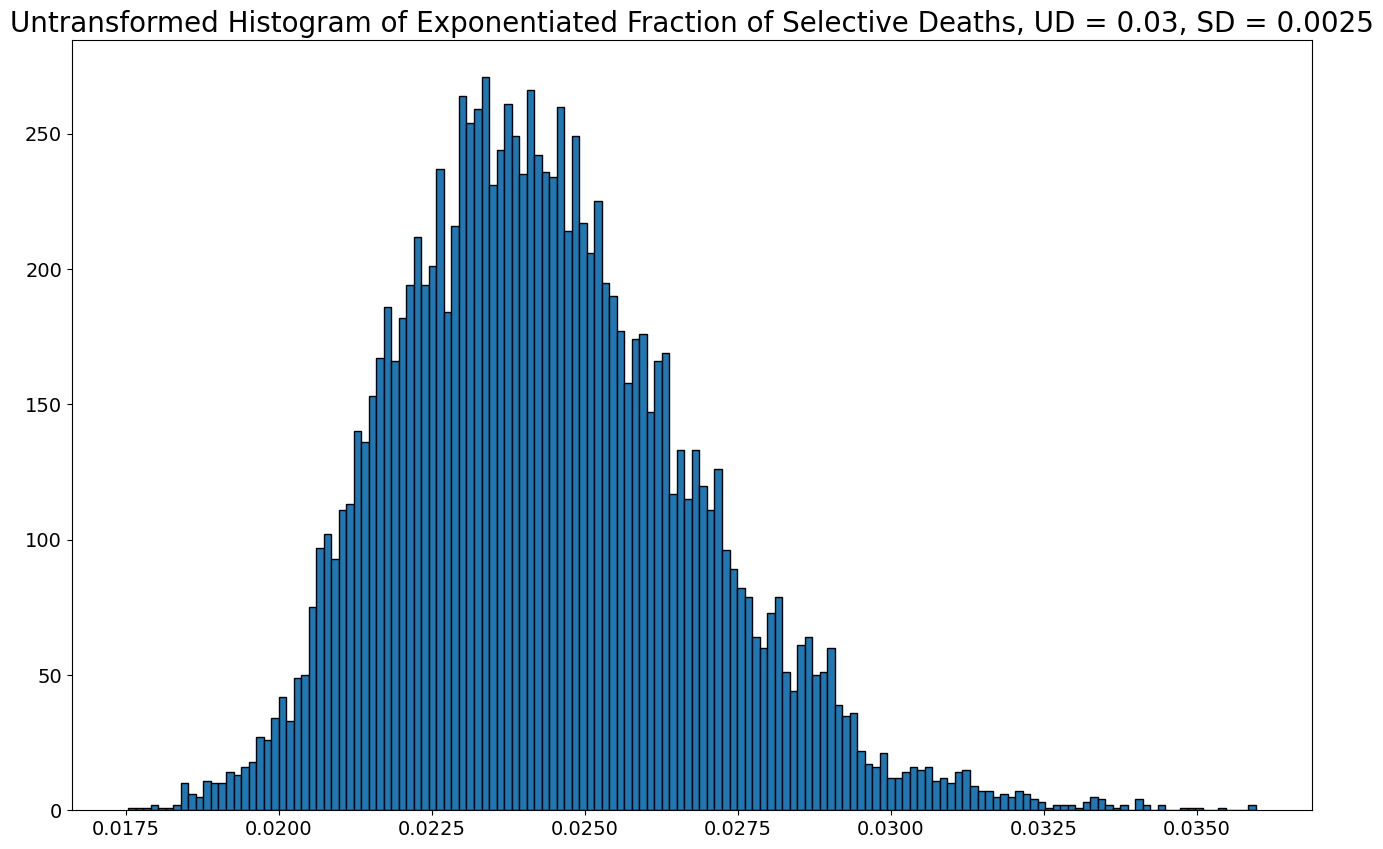

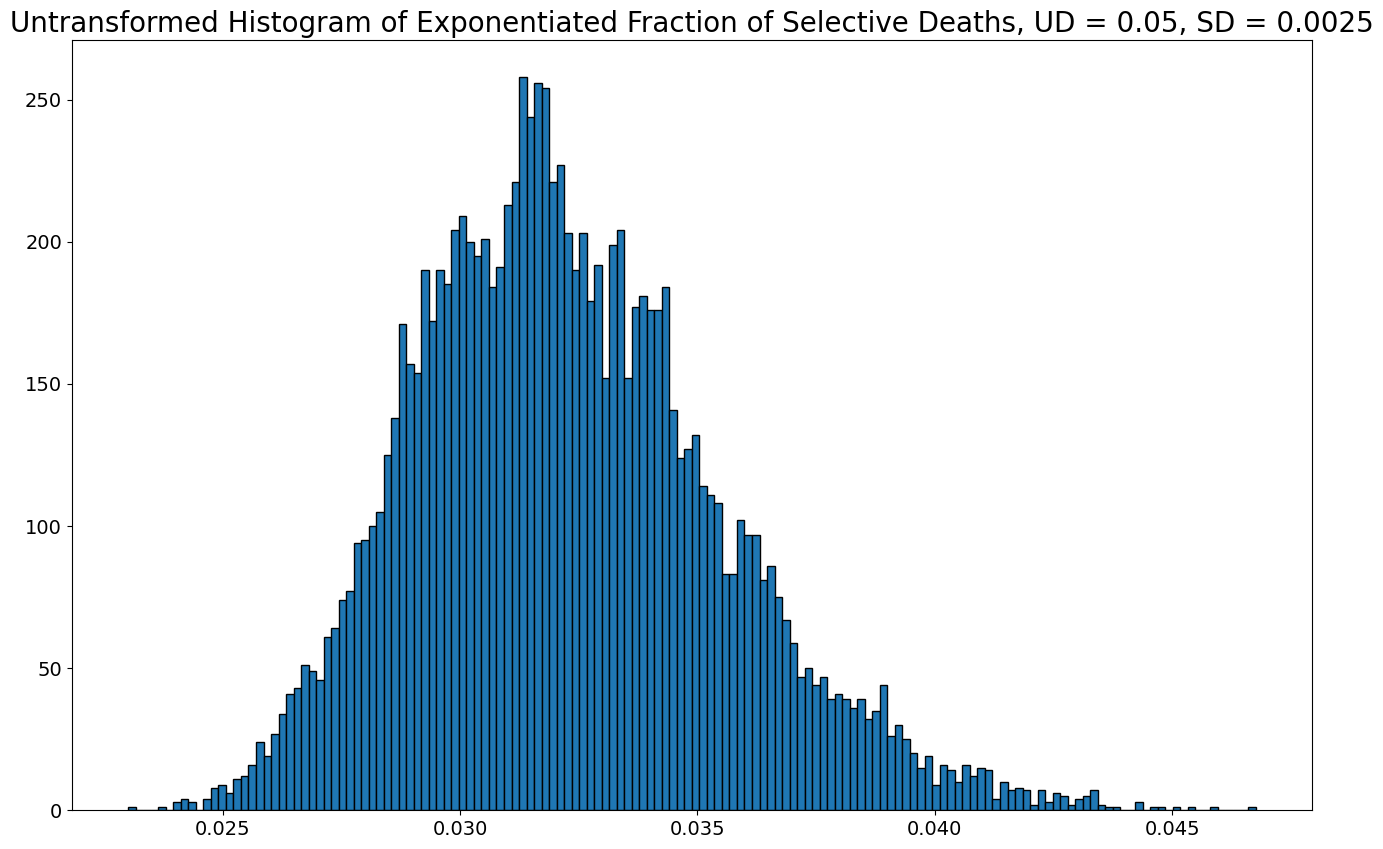

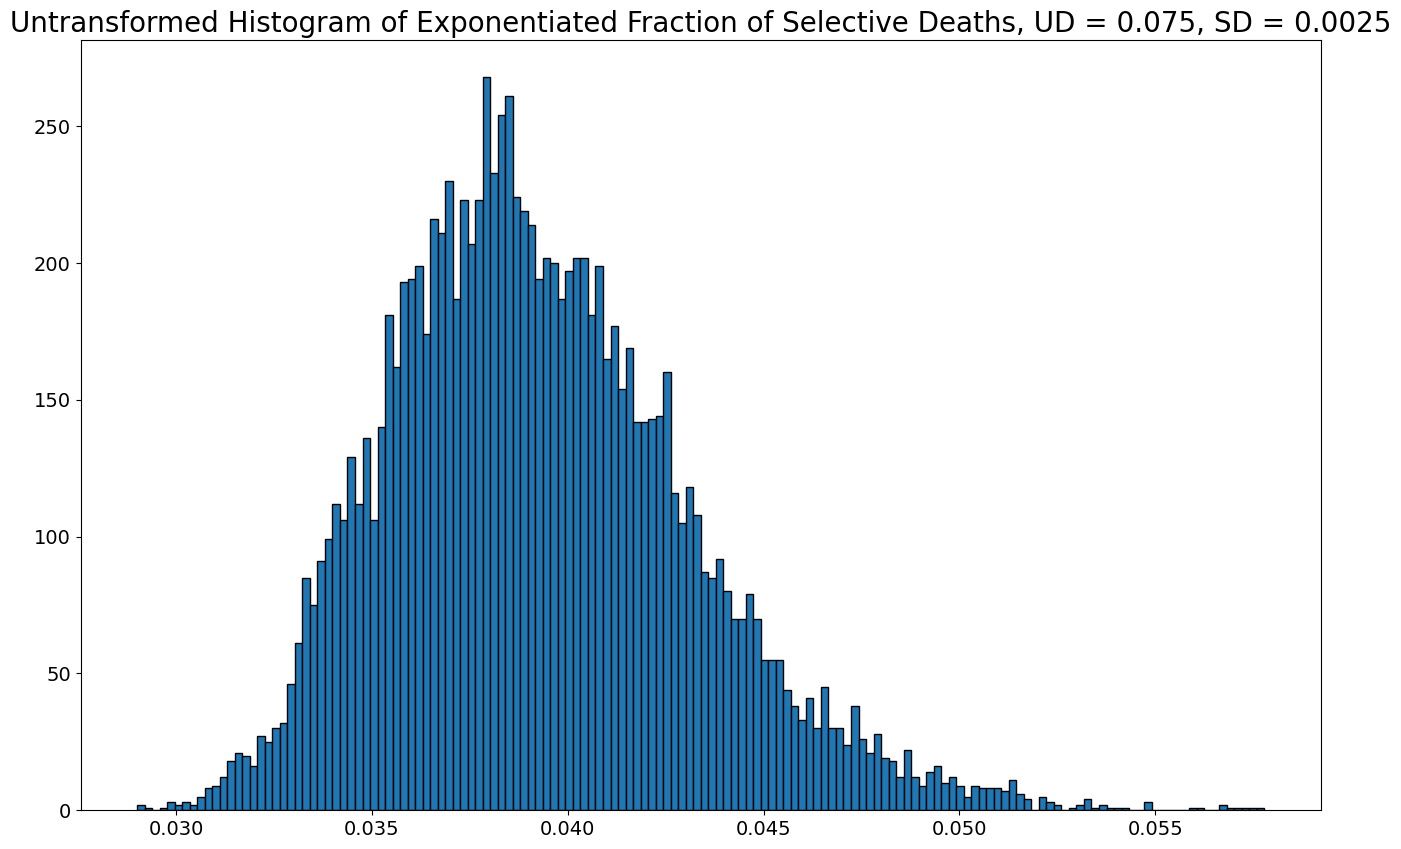

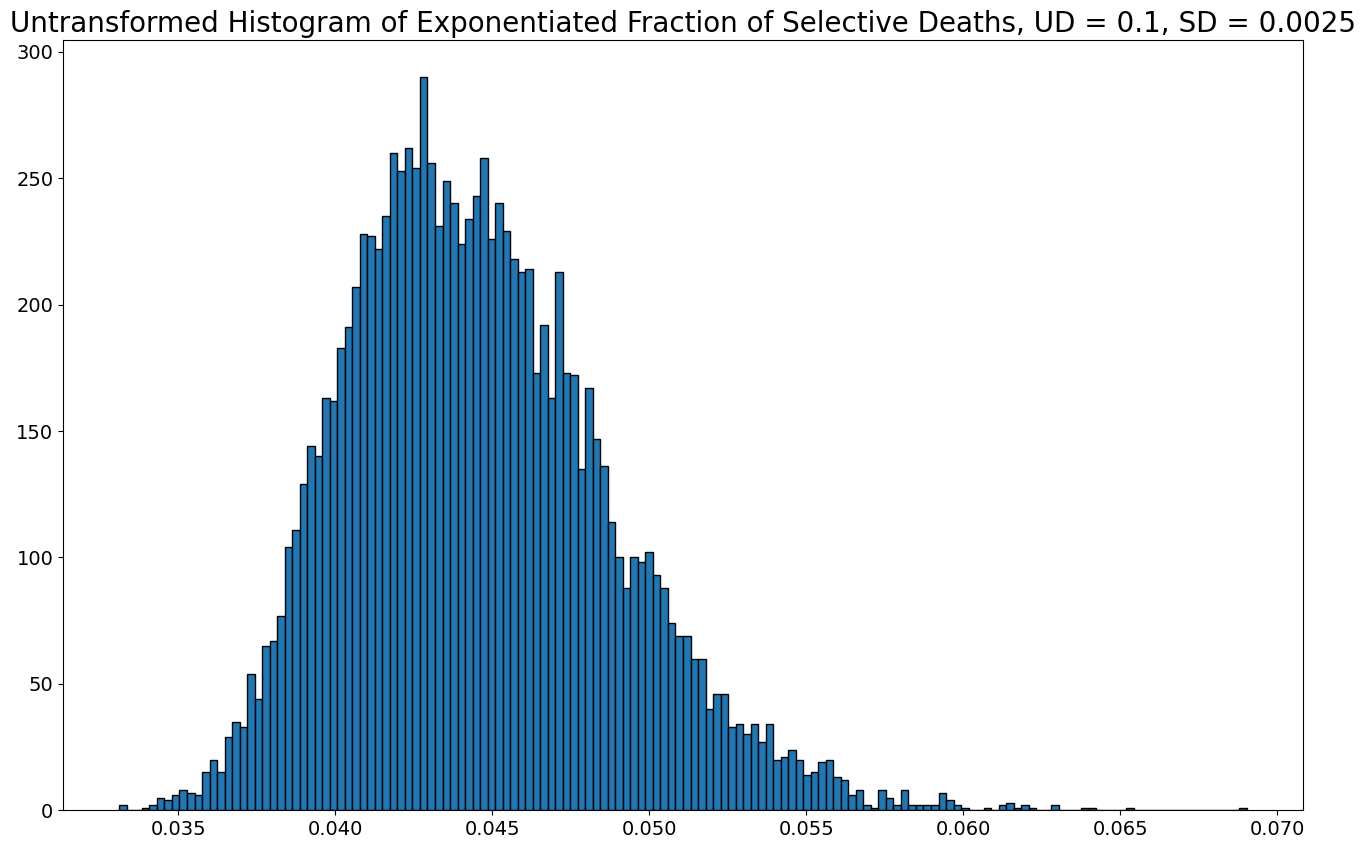

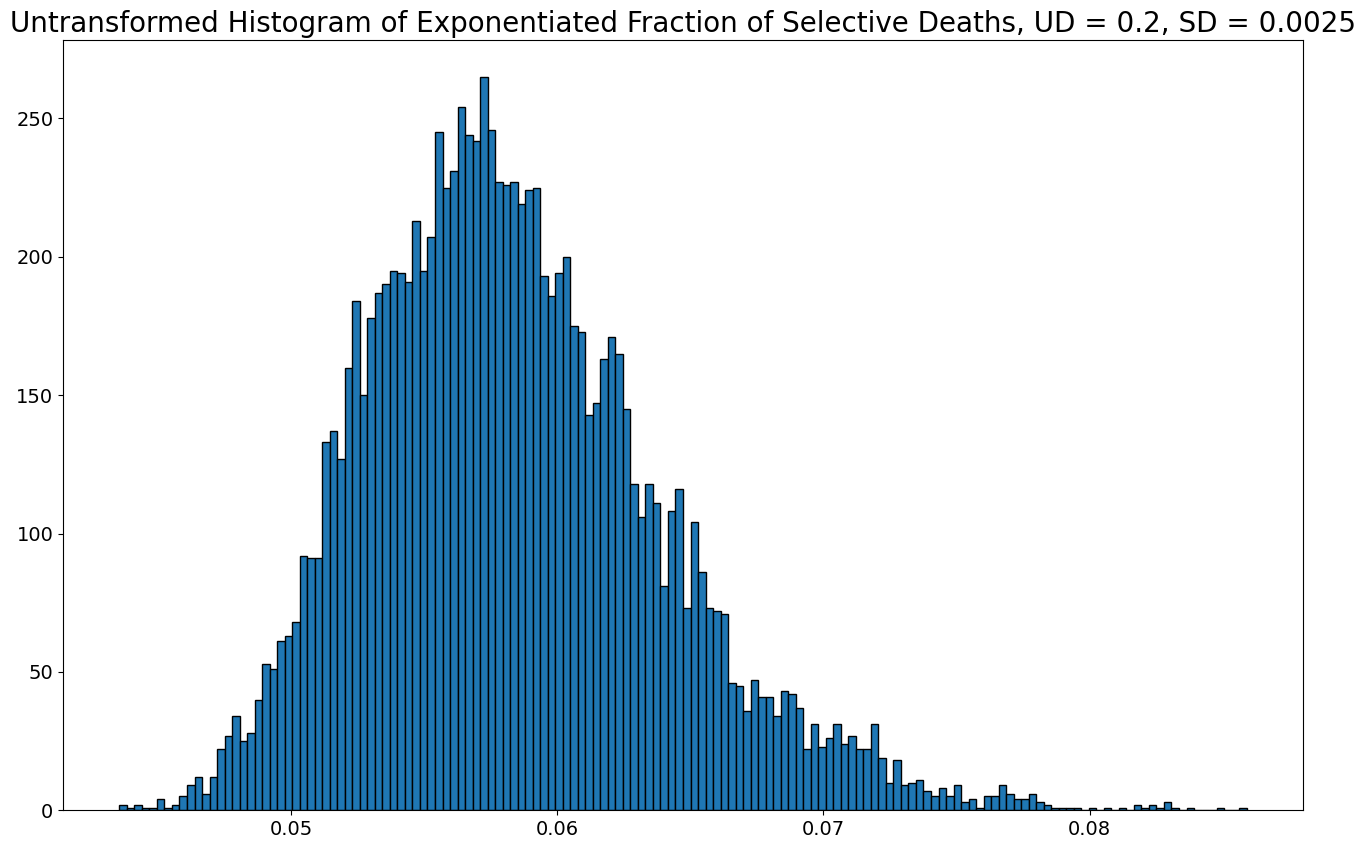

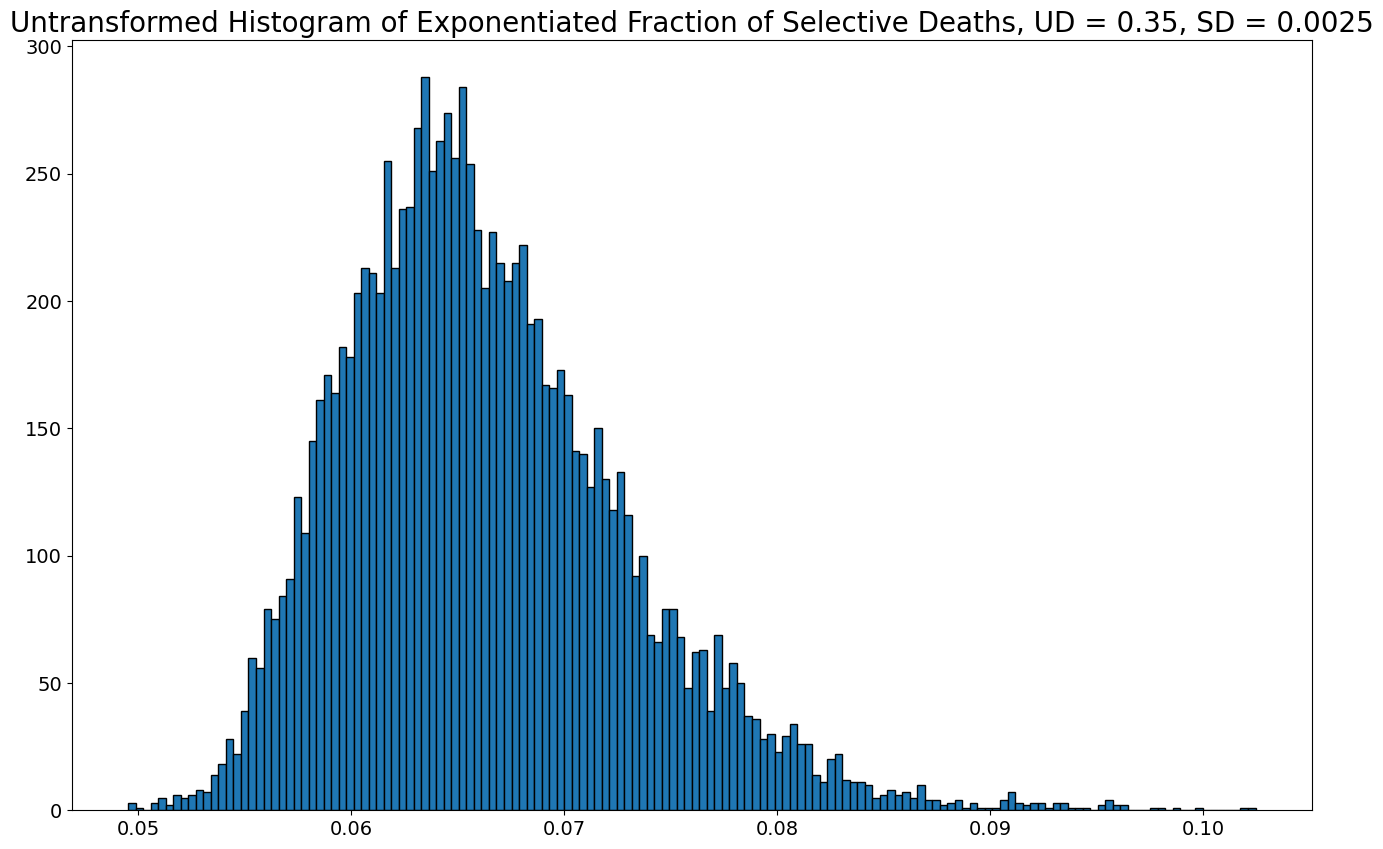

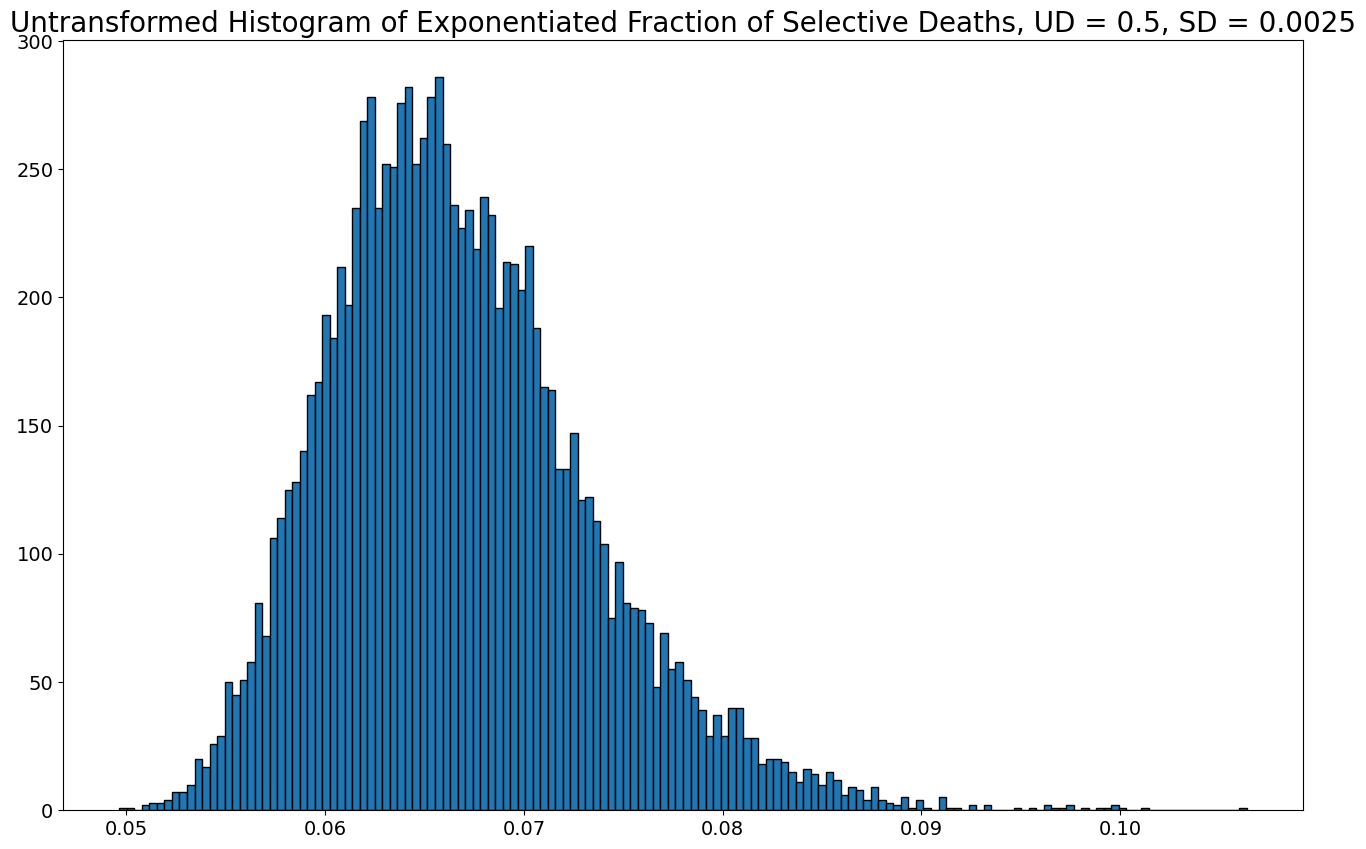

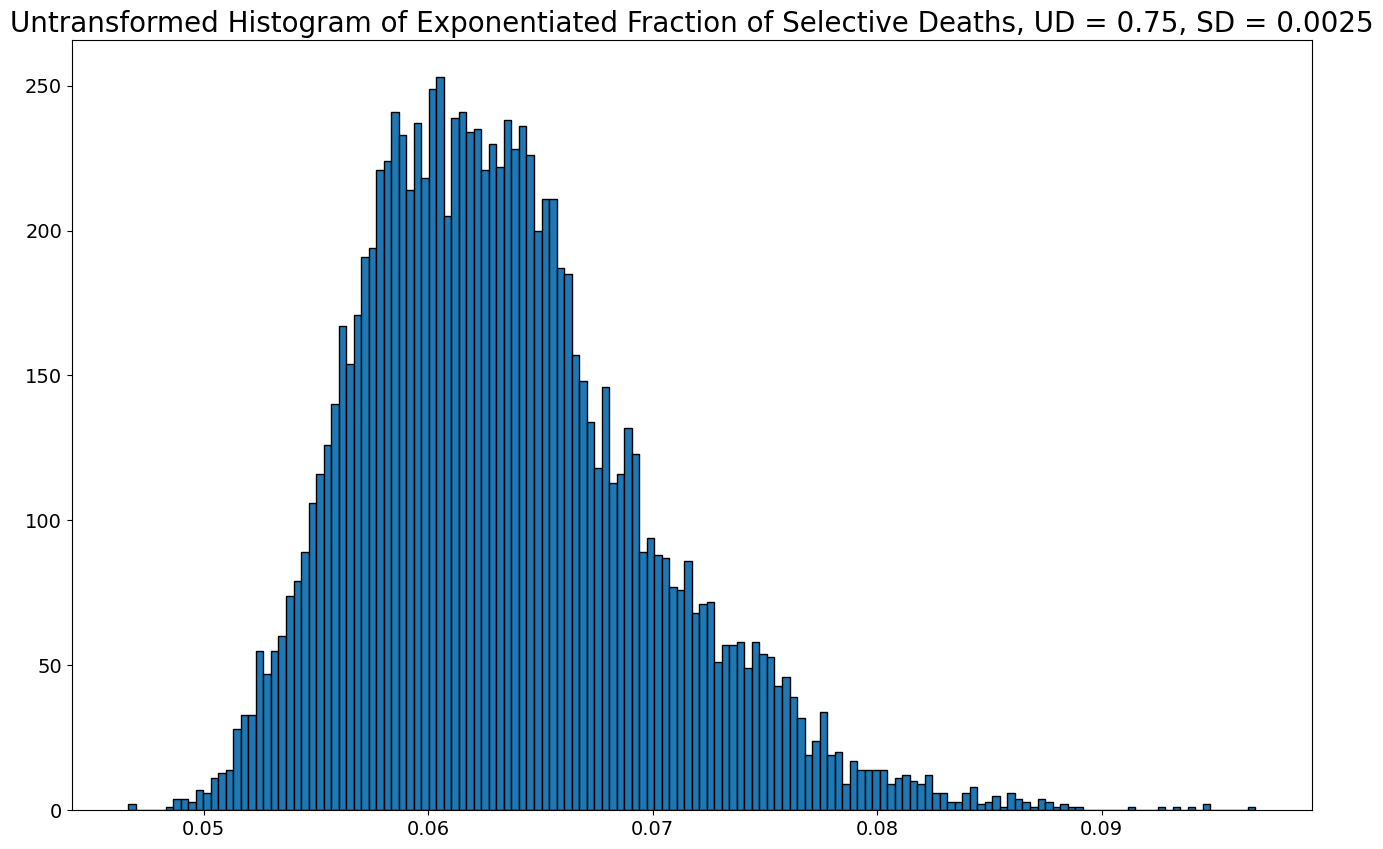

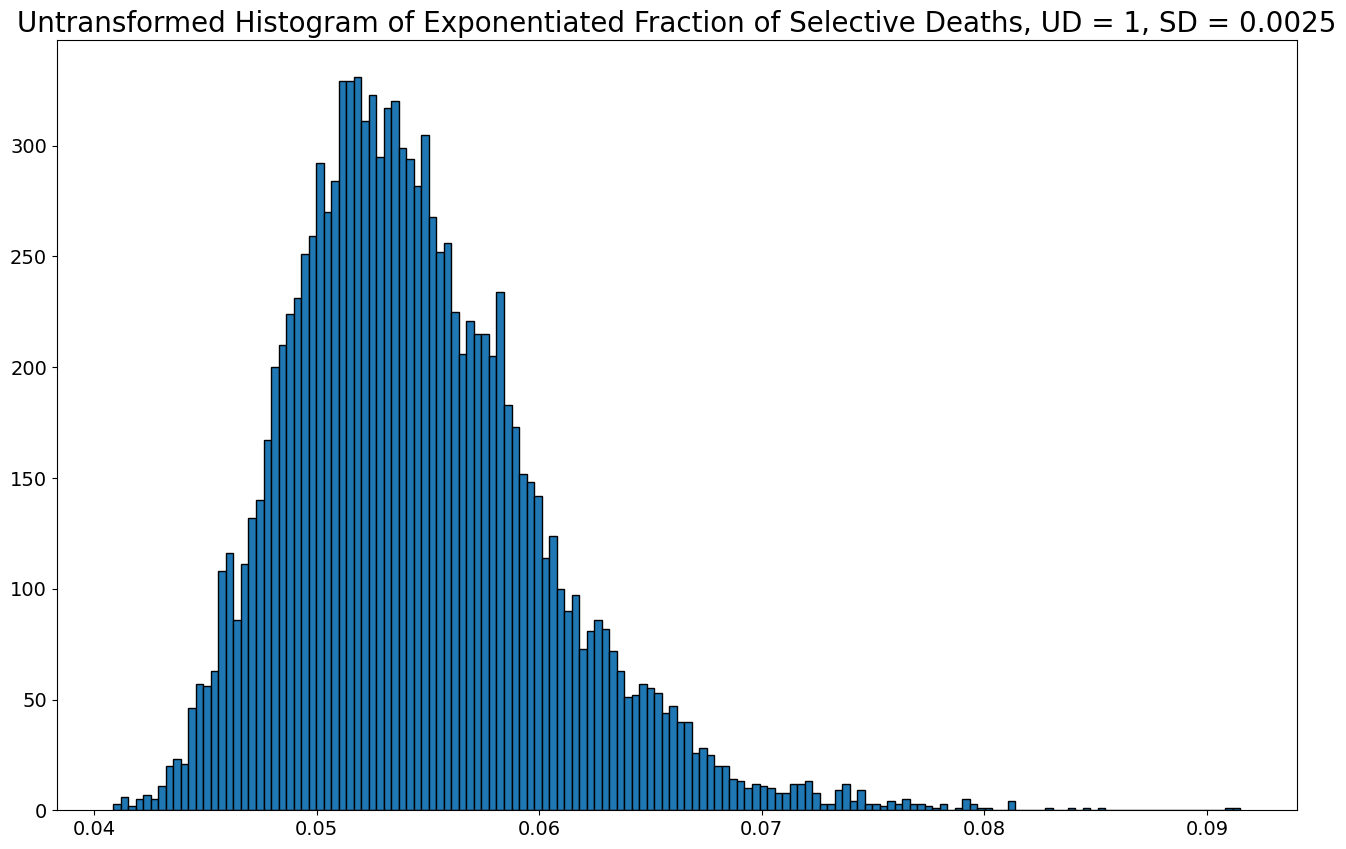

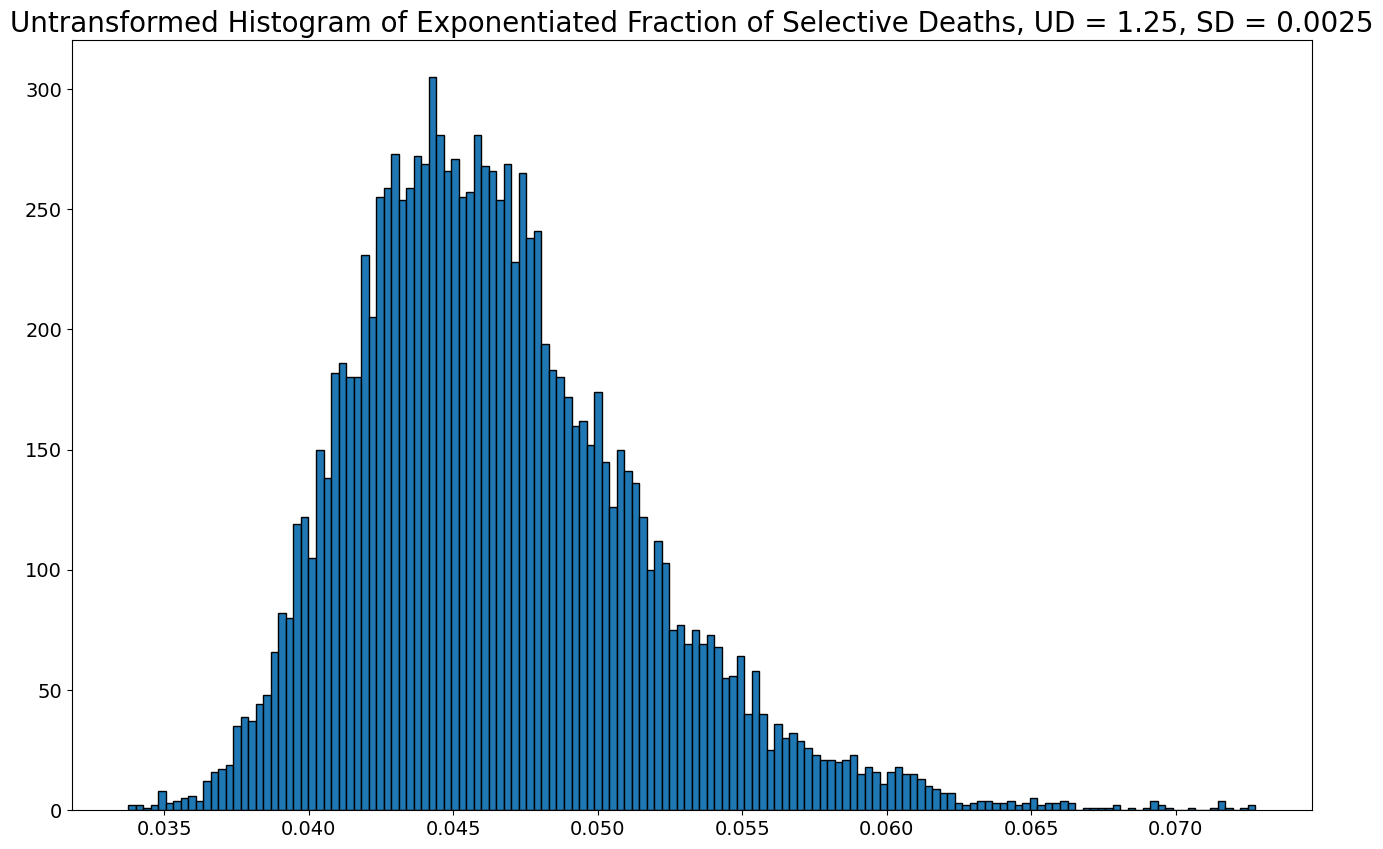

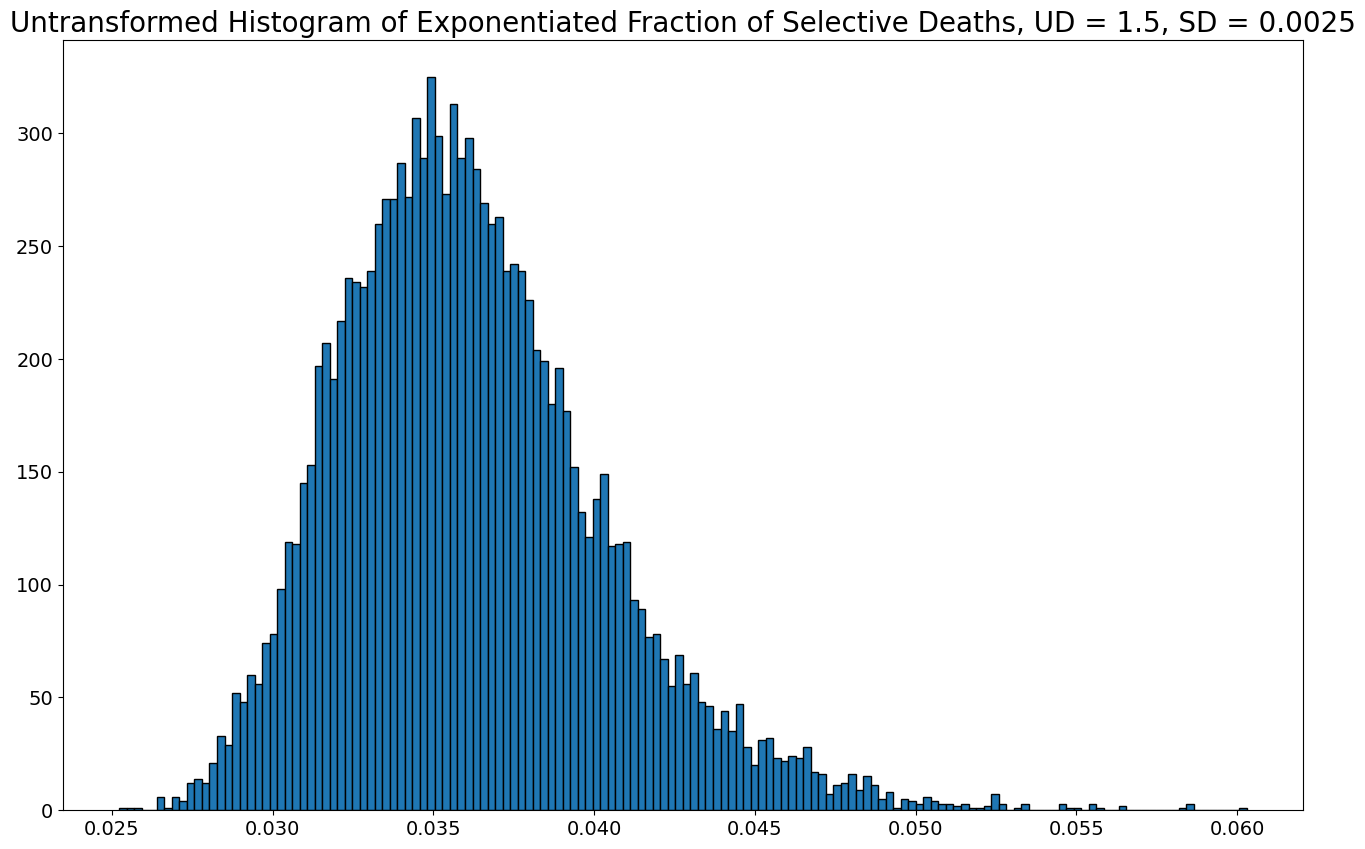

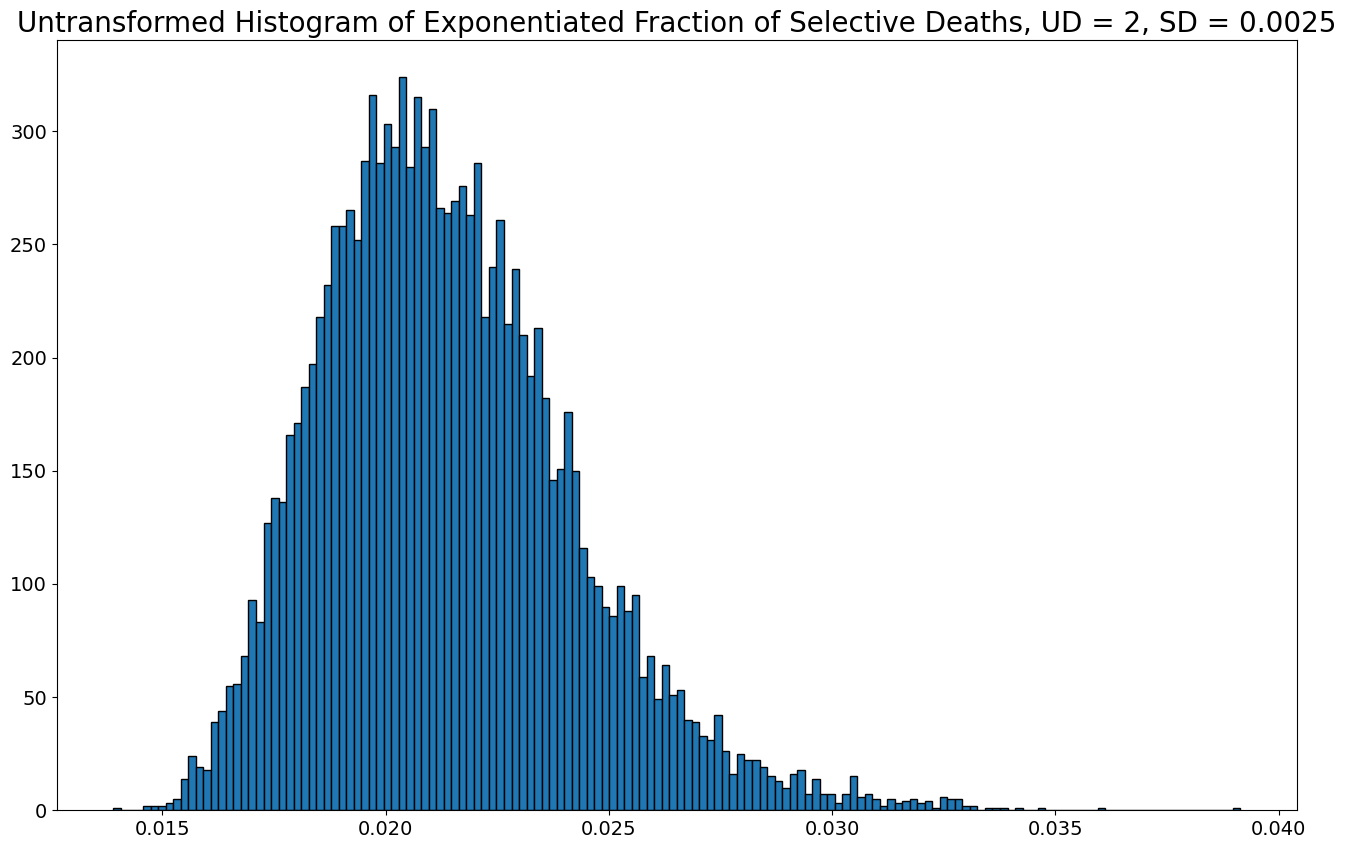

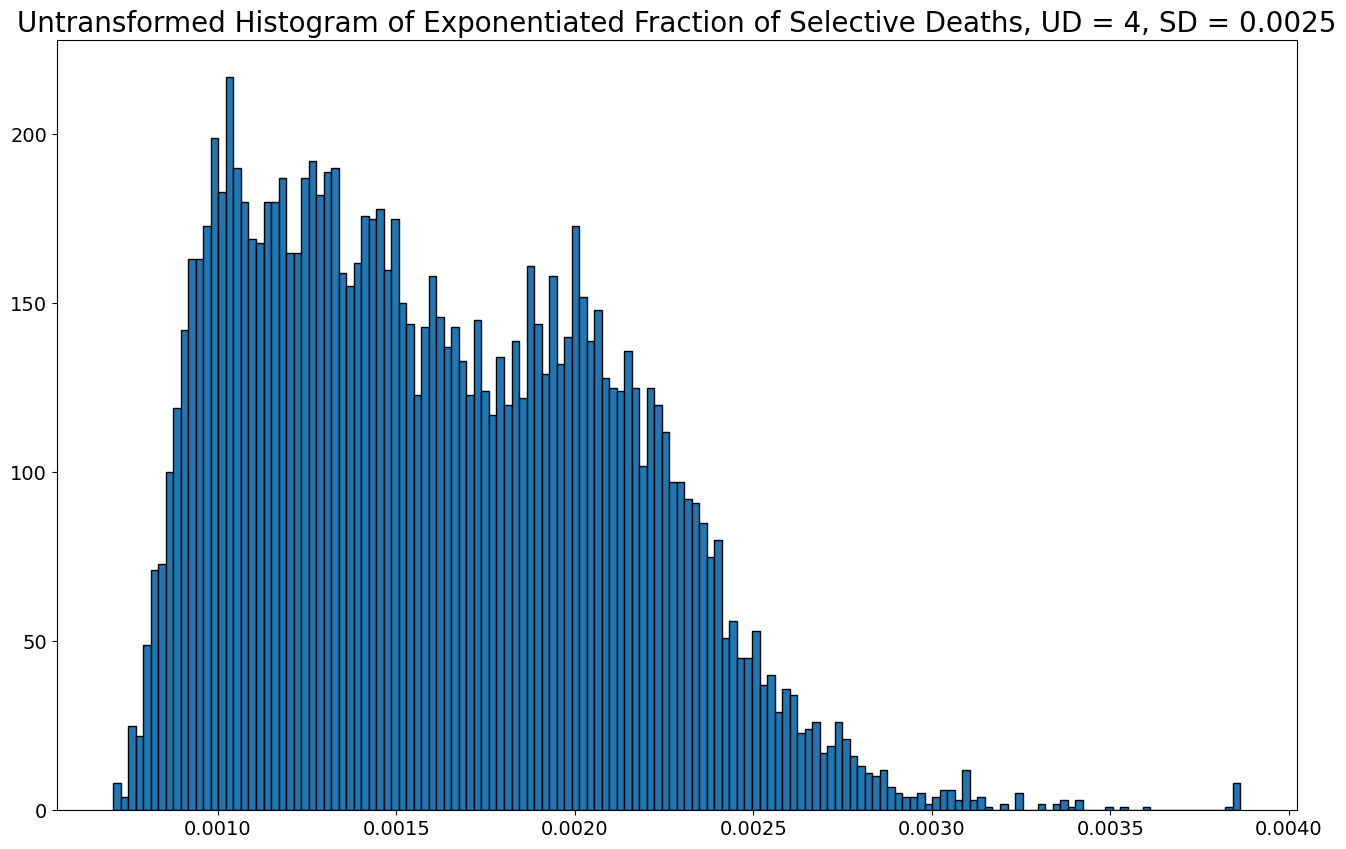

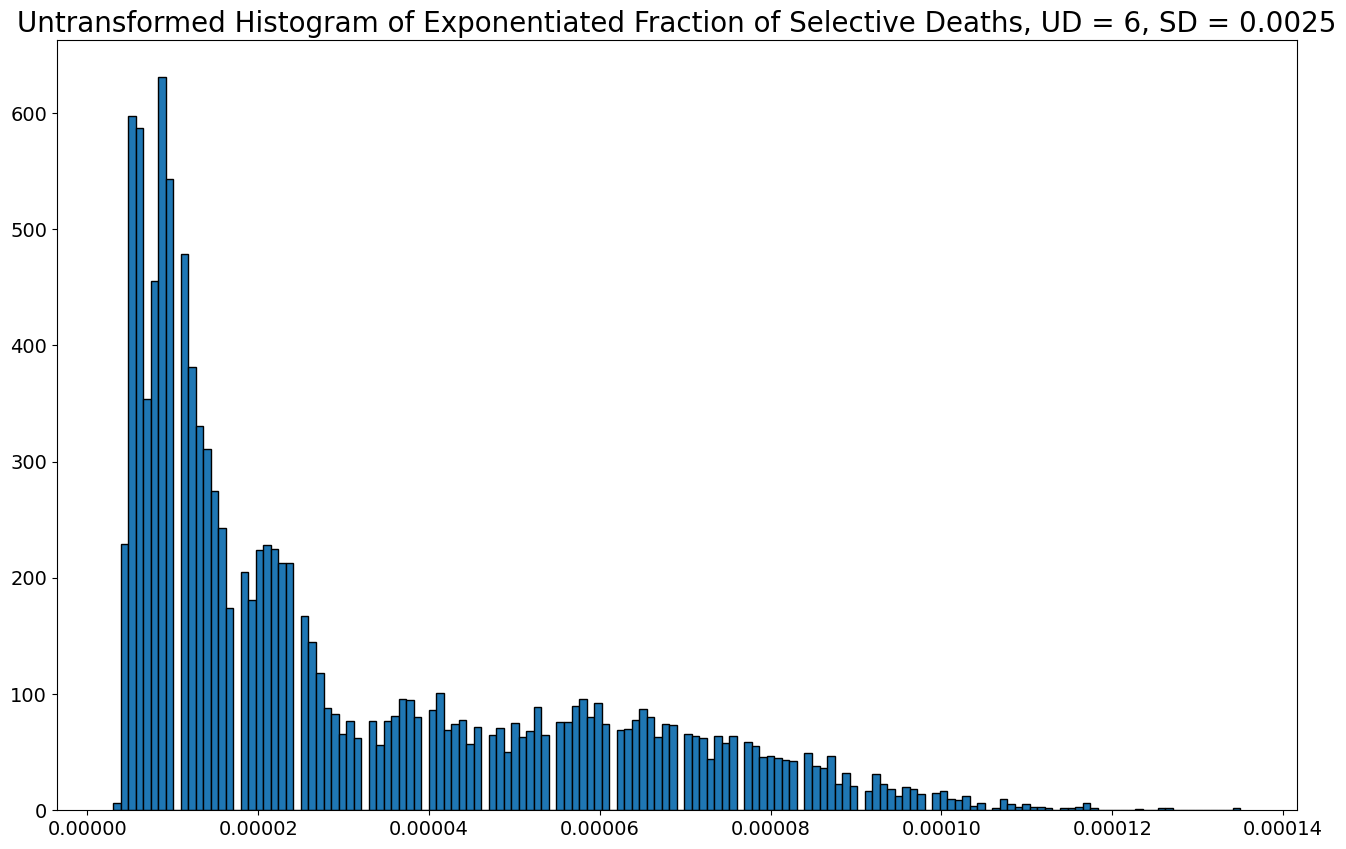

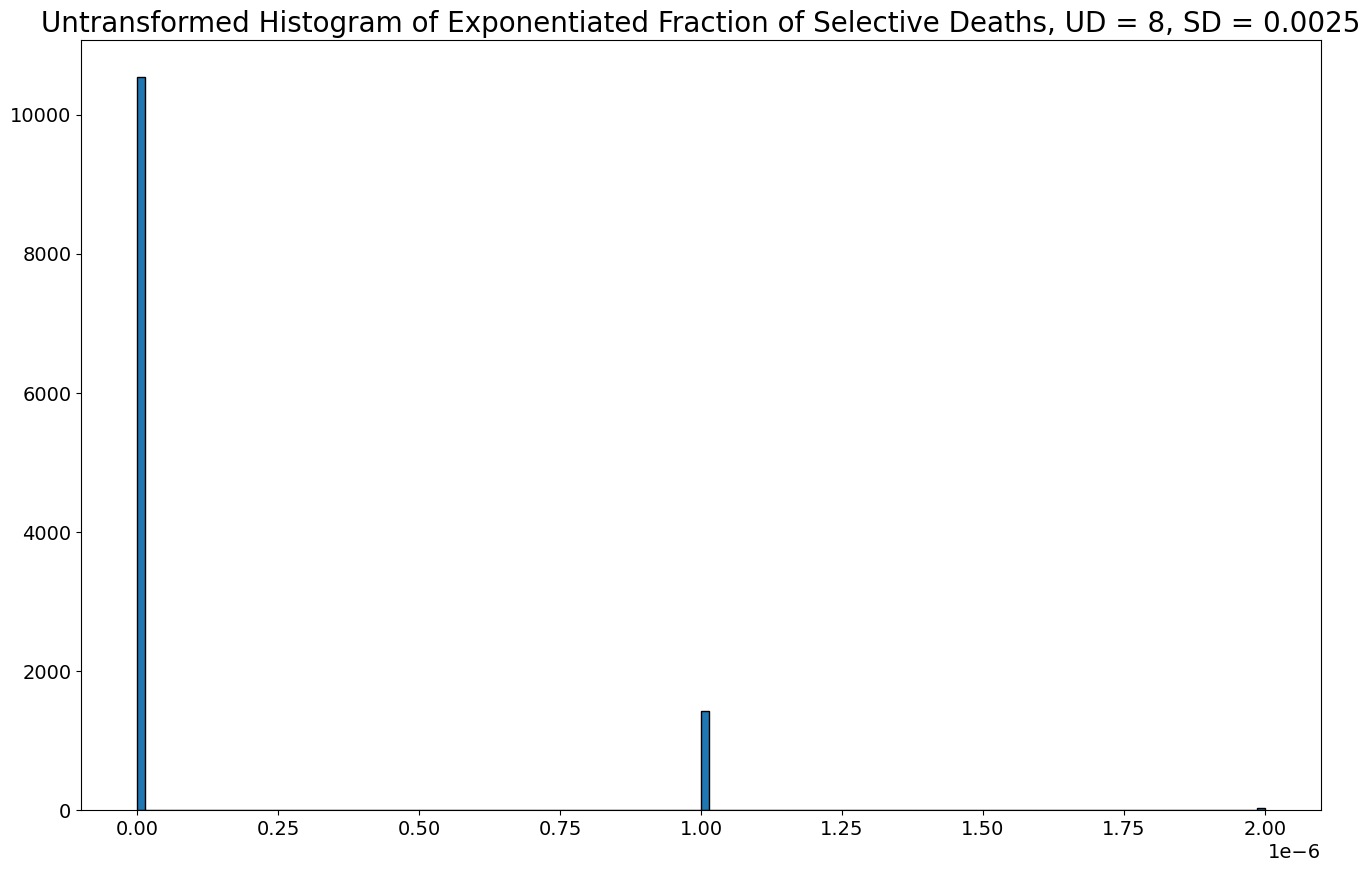

In [8]:
# S. Death Histograms: Burn-in, Untransformed

bin_count = 150 

for (sd, (ud, data)) in sliced_data: 
    plt.figure(figsize=(16, 10))
    plt.title("Untransformed Histogram of Exponentiated Fraction of Selective Deaths, UD = " + str(ud) + ", SD = " +(sd[3:]))
    plt.hist(data, bin_count, edgecolor = "black")
    "/Users/cameronliu/Desktop/Research/Exp Selective Death Histograms/Exp Untransformed"
    plt.savefig(f"/Users/cameronliu/Desktop/Research/Exp Selective Death Histograms/New Exp Untransformed/{sd[3:]}/" + str(sd) + "_exp_untrns_ud-" + str(ud) + "_histogram_bins-" + str(bin_count) + ".png", dpi=300, bbox_inches='tight')


In [12]:
# S. Death Histograms: Burn-in, Transformed

import cmath
plot = True

bin_count = 150 

transformed_datasets = parse_data.transform_data(sliced_data)

if plot:
    for ((sd, (ud, (transformed_data, transformed_lambda)))) in transformed_datasets: 
        plt.figure(figsize=(16, 10))
        plt.title("Exp Transformed Histogram of Exponential Fraction of Selective Deaths, UD = " + str(ud) + ", SD = " + str(sd[3:]) + " Lambda = " + str(transformed_lambda))
        plt.hist(transformed_data, bin_count, edgecolor = "black")
        
        plt.savefig(f"/Users/cameronliu/Desktop/Research/Exp Selective Death Histograms/New Exp Transformed/{sd[3:]}/" + str(sd) + "_trns_ud-" + str(ud) + "_histogram_bins-" + str(bin_count) + ".png", dpi=300, bbox_inches='tight')


False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False


ValueError: Data must be positive.

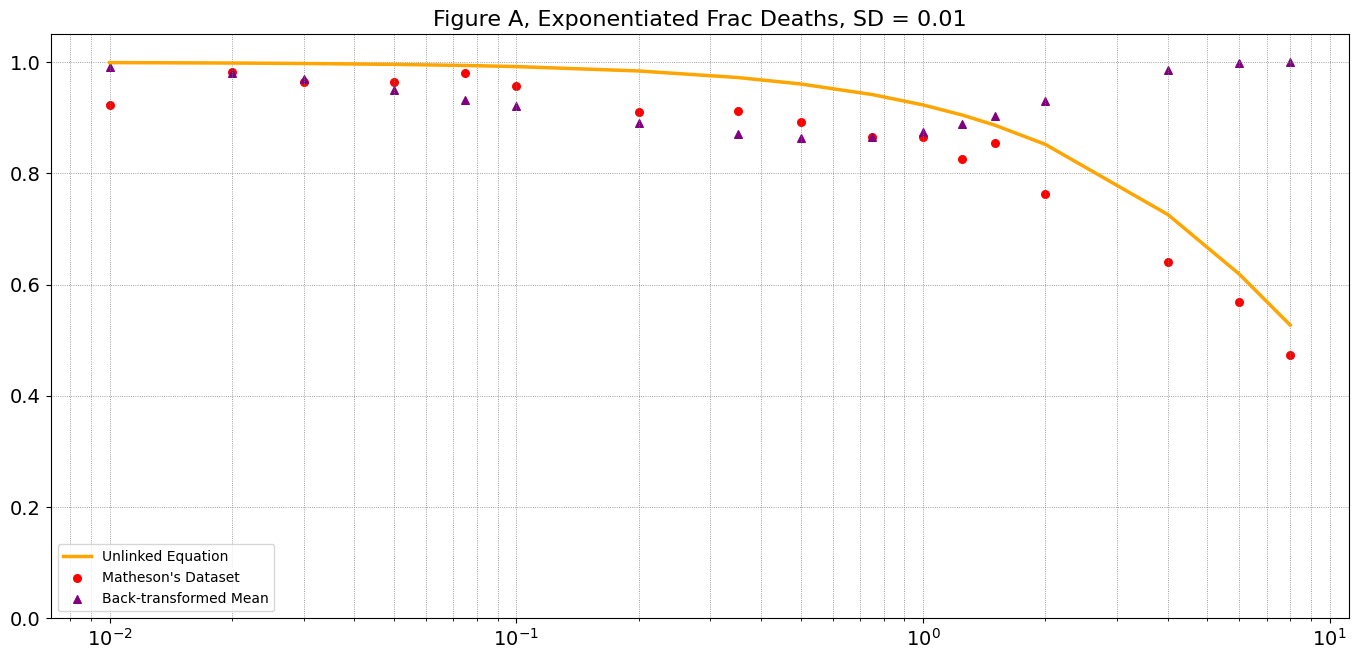

In [74]:
# Plotting the Comparison Graphs

# Getting the data 

# Back-transformed Datasets
transformed_datasets = parse_data.transform_data(sliced_data) # Transform the dataset 
back_transformed_uds = parse_data.back_transform(transformed_datasets) # Back-transform the dataset

# Matheson's raw dataset
matheson_dataset = parse_data.get_matheson_dataset(global_sd)

# Matheson's calculated ne from the unlinked equation
matheson_calculated_data = parse_data.calculate_matheson_data(uds, global_sd, False) 


# Unpack values
x_back_transformed, y_back_transformed = zip(*back_transformed_uds)
x_data, y_data = zip(*matheson_dataset)
x_calculated, y_calculated = zip(*matheson_calculated_data)


plt.figure(figsize=(14, 7))
plt.ylim(top=1.05) # sets it a bit higher than 1, so that way you can see those top values a bit better
plt.ylim(bottom=0)  # sets the lower y-limit to 0, always


# Ne/N line (solid orange line), calculate
plt.plot(x_calculated, y_calculated, color='orange', linewidth=2.5, label='Unlinked Equation')

# Matheson's raw dataset (red solid dots)
plt.scatter(x_data, y_data, color='red', s=30, label="Matheson's Dataset")

# Back-transformed values (purple solid dots)
plt.scatter(x_back_transformed, y_back_transformed, color='purple', s=30, marker='^', label='Back-transformed Mean')


# Determines Axis and Labels 
if global_sd == 0.01: 
    letter = "A"
elif global_sd == 0.0025: 
    letter = "B"
else: # 0.04
    letter = "C"

plt.title('Figure ' + letter + ', Exponentiated Frac Deaths, SD = ' + str(global_sd), fontsize=16)


# Log scale for x-axis
plt.xscale('log')

# Grid and legend
plt.grid(True, which='both', linestyle=':', linewidth=0.6)
plt.legend(loc='lower left', fontsize=10, frameon=True)


plt.tight_layout()
plt.savefig(f"/Users/cameronliu/Desktop/Research/Comparison Graphs/New Exponentiated/{global_sd}/comparison-sd-{global_sd}.png", dpi=300, bbox_inches='tight')

plt.show()
